# ML Position Sizing v2 — 10:30 Gate, Technical Indicators & Vol-Adjusted Sizing

**Base config:** W=55b | HR ≥ 0.80 | SP ≥ 0.70 | NY Session
**Exit:** Path B2 momentum reversal (K=7b, thr=−5 bps)

### What's new in v2

The original notebook had a critical pipeline failure: applying the 10:30 gate *together with* the SD filter inside `build_signal_frame` collapsed the OOS event count to **n=4** (and n=0 after ML filtering), making position sizing untestable.

This rebuild fixes the gate logic, adds technical-indicator features the ML classifier was missing, and replaces flat sizing with proper risk-parity sizing.

1. **Correct 10:30 gate** — gate trade *entries* at 10:30 ET while letting the 55-bar correlation window be built from 09:30 RTH data (no look-ahead). This filters the volatile NY open without throwing away signal-quality info.
2. **Indicator features for ML** — adds **SMA(20/50)**, **MACD(12/26/9)**, and **RSI(14)** computed on NQ at entry time. These give the classifier trend context the original 7 features lacked.
3. **Volatility-adjusted position sizing** — `size = TARGET_RISK_BPS / σ_NQ`, then scaled by ML probability (`2·(p−0.5)`) and clipped to `[0.25, 2.0]`. Replaces the placeholder flat-sizing block.

### Curves compared on OOS

| Curve | Signal | Exit | Sizing |
|---|---|---|---|
| 1 | Baseline (09:30, no SD filter)        | Fixed 35-min hold | Flat |
| 2 | Baseline                              | Path B2           | Flat |
| 3 | 10:30 gate (entries only) + SD band   | Path B2           | Flat |
| 4 | 10:30 gate + ML filter (rich features)| Path B2           | **Vol-adjusted** |


In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path("..").resolve()))


from src.data_pipeline import load_market_data, convert_index_timezone, add_calendar_features
from src.indicators import add_correlation_metrics, build_volume_analysis_frame
from src.simulation import build_signal_frame

# ── strategy constants ─────────────────────────────────────────────────────
WINDOW          = 55
HR_THRESH       = 0.80
SP_THRESH       = 0.70
FIXED_HOLD      = 35       # bars (1-min) — baseline
B2_K            = 7        # Path B2 reversal look-back
B2_THR_BPS      = -5.0     # Path B2 exit threshold (bps)
MAX_HOLD        = 60       # hard cap (bars)
IS_RATIO        = 0.70     # in-sample fraction (chronological)

# ── 10:30 gate ─────────────────────────────────────────────────────────────
ENTRY_GATE_TIME = "10:30"  # earliest allowed entry (ET) — skips NY open vol
SESSION_END     = "16:00"  # NY close

# ── SD volatility band (within gated session) ──────────────────────────────
STD_LOW_PCT     = 0.20
STD_HIGH_PCT    = 0.80

# ── Technical indicator parameters ─────────────────────────────────────────
SMA_FAST        = 20
SMA_SLOW        = 50
MACD_FAST       = 12
MACD_SLOW       = 26
MACD_SIGNAL     = 9
RSI_PERIOD      = 14

# ── Position sizing ────────────────────────────────────────────────────────
TARGET_RISK_BPS = 10.0     # per-trade risk target (bps of NQ 1-min std)
MIN_SIZE        = 0.25     # floor — never below 1/4 unit
MAX_SIZE        = 2.00     # cap   — never above 2 units

# ── ML feature set (v2: + SMA, MACD, RSI) ──────────────────────────────────
FEATURE_COLS = [
    # original features
    "hit_ratio", "corr_spearman", "mom_window",
    "rolling_std_nq", "conviction_score",
    "hour_sin", "hour_cos",
    # NEW — technical indicators on NQ at entry
    "sma_fast_dist",     # (price - SMA20) / price
    "sma_slow_dist",     # (price - SMA50) / price
    "sma_cross",         # (SMA20 - SMA50) / price  — trend strength
    "macd",              # MACD line (normalized by price)
    "macd_signal",       # signal line
    "macd_hist",         # histogram (momentum)
    "rsi",               # RSI(14) — overbought/oversold
]

print(f"Imports OK | {len(FEATURE_COLS)} features in ML pipeline")


Imports OK | 14 features in ML pipeline


## 1. Data Loading & Correlation Metrics

The 55-bar correlation window is computed on **all RTH bars from 09:30**.
This is critical: if we restricted observation to 10:30+, we'd lose half of the pre-open setup information that defines the signal quality. The 10:30 gate is applied later, *only* to entries.


In [2]:
df_raw = load_market_data()
df     = convert_index_timezone(df_raw, "America/New_York")
df     = add_calendar_features(df)

# Correlation metrics (Spearman, hit_ratio, Pearson) — W=55
metrics_df = add_correlation_metrics(df, window=WINDOW)

# Momentum regime direction — same look-back as signal window
metrics_df["mom_window"]  = (
    metrics_df["nq_close"] / metrics_df["nq_close"].shift(WINDOW) - 1
)
metrics_df["regime_dir"] = np.sign(metrics_df["mom_window"]).replace(0, 1)

# Rolling NQ return std — used for SD filter AND vol-adjusted position sizing
metrics_df["rolling_std_nq"] = (
    metrics_df["nq_ret"].rolling(window=WINDOW).std()
)

# Fixed-hold forward returns for Curve 1 baseline
metrics_df["nq_fwd_35"] = (
    metrics_df["nq_close"].shift(-FIXED_HOLD) / metrics_df["nq_close"] - 1
)

# Volume-weighted features — provides conviction_score
volume_df = build_volume_analysis_frame(metrics_df, window=WINDOW)

print(f"Aligned bars : {len(metrics_df):,}")
print(f"Date range   : {metrics_df.index[0]:%Y-%m-%d} → {metrics_df.index[-1]:%Y-%m-%d}")


Aligned bars : 682,008
Date range   : 2024-03-07 → 2026-03-06


## 2. Technical Indicator Engineering — SMA, MACD, RSI

All three indicators are computed on `nq_close` at every bar of the dataset.
At ML feature-extraction time they're sampled at the entry timestamp — no look-ahead since each indicator uses only past prices.

| Indicator | Why it's here |
|---|---|
| **SMA(20) & SMA(50)** | Trend context. A signal entered when NQ is far above the 50-SMA in a long-regime is structurally different from one entered near the SMA. We use *distance* and *cross spread* rather than raw SMA so features are stationary. |
| **MACD(12/26/9)** | Momentum convergence/divergence. The histogram (MACD − signal) captures whether momentum is accelerating or stalling at entry — a key tell for B2 reversal risk. |
| **RSI(14)** | Overbought/oversold context. Long-regime entries with RSI > 70 are systematically more vulnerable to reversal; the classifier can learn this if we give it the feature. |

All indicators are normalized (divided by price where relevant) so the logistic regression's coefficients are interpretable across price levels.


In [3]:
def compute_sma(close: pd.Series, period: int) -> pd.Series:
    return close.rolling(window=period, min_periods=period).mean()


def compute_macd(close: pd.Series,
                 fast: int = 12, slow: int = 26, signal: int = 9
                 ) -> tuple[pd.Series, pd.Series, pd.Series]:
    ema_fast = close.ewm(span=fast,   adjust=False, min_periods=fast).mean()
    ema_slow = close.ewm(span=slow,   adjust=False, min_periods=slow).mean()
    macd_line   = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False, min_periods=signal).mean()
    histogram   = macd_line - signal_line
    return macd_line, signal_line, histogram


def compute_rsi(close: pd.Series, period: int = 14) -> pd.Series:
    delta  = close.diff()
    gain   = delta.clip(lower=0)
    loss   = -delta.clip(upper=0)
    # Wilder's smoothing
    avg_g  = gain.ewm(alpha=1/period, adjust=False, min_periods=period).mean()
    avg_l  = loss.ewm(alpha=1/period, adjust=False, min_periods=period).mean()
    rs     = avg_g / avg_l.replace(0, np.nan)
    rsi    = 100 - (100 / (1 + rs))
    return rsi.fillna(50.0)  # neutral when undefined


# ── attach to metrics_df ───────────────────────────────────────────────────
price = metrics_df["nq_close"]

sma_fast = compute_sma(price, SMA_FAST)
sma_slow = compute_sma(price, SMA_SLOW)
metrics_df["sma_fast_dist"] = (price - sma_fast) / price
metrics_df["sma_slow_dist"] = (price - sma_slow) / price
metrics_df["sma_cross"]     = (sma_fast - sma_slow) / price

macd_line, signal_line, hist = compute_macd(price, MACD_FAST, MACD_SLOW, MACD_SIGNAL)
metrics_df["macd"]        = macd_line   / price
metrics_df["macd_signal"] = signal_line / price
metrics_df["macd_hist"]   = hist        / price

metrics_df["rsi"] = compute_rsi(price, RSI_PERIOD)

print("Technical indicators computed on every bar:")
ind_cols = ["sma_fast_dist", "sma_slow_dist", "sma_cross",
            "macd", "macd_signal", "macd_hist", "rsi"]
print(metrics_df[ind_cols].describe().T[["mean", "std", "min", "max"]].round(5))


Technical indicators computed on every bar:
                   mean       std      min        max
sma_fast_dist   0.00000   0.00089 -0.04853    0.04296
sma_slow_dist   0.00001   0.00144 -0.05191    0.06322
sma_cross       0.00001   0.00088 -0.02775    0.03060
macd            0.00000   0.00041 -0.01378    0.01628
macd_signal     0.00000   0.00038 -0.01123    0.01338
macd_hist       0.00000   0.00012 -0.00632    0.00516
rsi            50.71831  11.77076  2.62167  100.00000


## 3. Baseline Signal Events (Curves 1 & 2)

Reproduces the original 09:30-session, no-volatility-filter signal set so Curves 1 and 2 stay comparable to the prior benchmark.


In [4]:
baseline_sig = build_signal_frame(
    metrics_df,
    session_start="09:30",
    hit_ratio_threshold=HR_THRESH,
    spearman_threshold=SP_THRESH,
    std_low_pct=0.0,   # disable SD filter
    std_high_pct=1.0,
)
baseline_events = baseline_sig[baseline_sig["event_start"]].copy()
baseline_events["conviction_score"] = (
    volume_df["conviction_score"].reindex(baseline_events.index)
)

# IS / OOS split — chronological, shared across all curves
oos_start_ts = baseline_events.index[int(len(baseline_events) * IS_RATIO)]

print(f"Baseline events  : {len(baseline_events)}")
print(f"OOS period starts: {oos_start_ts:%Y-%m-%d %H:%M}")
print(f"  IS events : {(baseline_events.index <  oos_start_ts).sum()}")
print(f"  OOS events: {(baseline_events.index >= oos_start_ts).sum()}")


Baseline events  : 466
OOS period starts: 2025-08-29 10:57
  IS events : 326
  OOS events: 140


## 4. Path B2 Exit Simulator

Walk forward bar-by-bar; exit on the first bar where the rolling K-bar NQ return (in trade direction) falls below the threshold. Hard cap 60 bars.


In [5]:
def simulate_path_b2(
    df_full: pd.DataFrame,
    events: pd.DataFrame,
    k: int   = B2_K,
    thr_bps: float = B2_THR_BPS,
    max_hold: int  = MAX_HOLD,
) -> pd.DataFrame:
    """Simulate Path B2 momentum-reversal exits for each entry."""
    nq   = df_full["nq_close"].values
    idx  = {ts: i for i, ts in enumerate(df_full.index)}
    thr  = thr_bps / 10_000
    rows = []

    for entry_ts, row in events.iterrows():
        direction = row["regime_dir"]
        start = idx.get(entry_ts)
        if start is None:
            rows.append({"entry_ts": entry_ts, "realized_bps": np.nan,
                         "hold_bars": np.nan, "exit_reason": "missing"})
            continue

        entry_price = nq[start]
        exit_bar = start + max_hold
        reason   = "time_cap"

        for t in range(1, max_hold + 1):
            bar = start + t
            if bar >= len(nq):
                exit_bar = bar - 1
                reason   = "end_of_data"
                break
            k_ret = (nq[bar] / nq[max(0, bar - k)] - 1) * direction
            if k_ret < thr:
                exit_bar = bar
                reason   = "b2_reversal"
                break

        realized = (
            (nq[exit_bar] / entry_price - 1) * direction * 10_000
            if exit_bar < len(nq) else np.nan
        )
        rows.append({
            "entry_ts":     entry_ts,
            "realized_bps": realized,
            "hold_bars":    exit_bar - start,
            "exit_reason":  reason,
        })

    return pd.DataFrame(rows).set_index("entry_ts")


baseline_b2 = simulate_path_b2(metrics_df, baseline_events)
print("Baseline events — Path B2 exit")
print(f"  n trades  : {baseline_b2['realized_bps'].notna().sum()}")
print(f"  Win rate  : {(baseline_b2['realized_bps'] > 0).mean()*100:.1f}%")
print(f"  Avg bps   : {baseline_b2['realized_bps'].mean():.2f}")
print(f"  Avg hold  : {baseline_b2['hold_bars'].mean():.1f} bars")


Baseline events — Path B2 exit
  n trades  : 466
  Win rate  : 39.1%
  Avg bps   : 2.49
  Avg hold  : 9.1 bars


## 5. 10:30 Entry Gate — Correct Logic

### The bug in v1

The original notebook passed `session_start="10:30"` into `build_signal_frame`, which restricted both the correlation observation window *and* entries to the post-10:30 session. That had two consequences:

1. The 55-bar Spearman/HR window starting at 10:30 doesn't have enough pre-open bars to characterize the day's regime — quality of the gate metric drops.
2. Combined with the `std_low_pct=0.20, std_high_pct=0.80` band (which is recomputed *inside* the gated session), only **17 events** survived out of 466 — and only **4** fell in the OOS period.

### The fix

We keep the correlation window flowing from 09:30 RTH bars (full information) and apply the 10:30 gate as a separate **entry filter** on the resulting events. The SD band is then computed on the *distribution of `rolling_std_nq` at gated-entry timestamps*, so the 20–80 percentile band reflects the volatility regime of the trading window itself — not the all-day distribution.

This preserves signal quality while filtering out NY-open chaos.


In [6]:
# Step 1 — full-RTH baseline (same as Curves 1 & 2 source)
full_rth_sig = build_signal_frame(
    metrics_df,
    session_start="09:30",
    hit_ratio_threshold=HR_THRESH,
    spearman_threshold=SP_THRESH,
    std_low_pct=0.0,
    std_high_pct=1.0,
)
full_rth_events = full_rth_sig[full_rth_sig["event_start"]].copy()

# Step 2 — apply 10:30 entry gate (volatility-of-NY-open filter)
entry_times    = full_rth_events.index.time
gate_threshold = pd.Timestamp(f"2000-01-01 {ENTRY_GATE_TIME}").time()
session_close  = pd.Timestamp(f"2000-01-01 {SESSION_END}").time()
gate_mask      = (entry_times >= gate_threshold) & (entry_times < session_close)
gated_events   = full_rth_events[gate_mask].copy()

# Step 3 — recompute SD band on gated-entry distribution
std_at_gated   = gated_events["rolling_std_nq"].dropna()
std_low_cut    = std_at_gated.quantile(STD_LOW_PCT)
std_high_cut   = std_at_gated.quantile(STD_HIGH_PCT)
sd_mask        = gated_events["rolling_std_nq"].between(std_low_cut, std_high_cut)
gated_filtered = gated_events[sd_mask].copy()

gated_filtered["conviction_score"] = (
    volume_df["conviction_score"].reindex(gated_filtered.index)
)

print(f"Full-RTH events                            : {len(full_rth_events)}")
print(f"After 10:30 entry gate                     : {len(gated_events)}  "
      f"(-{len(full_rth_events)-len(gated_events)})")
print(f"After SD band [{STD_LOW_PCT:.0%}-{STD_HIGH_PCT:.0%}] within gated session : "
      f"{len(gated_filtered)}  (-{len(gated_events)-len(gated_filtered)})")
print(f"SD band thresholds                          : "
      f"low={std_low_cut:.6f}  high={std_high_cut:.6f}")

# Distribution of entry hours after gate
hour_dist = pd.Series(gated_filtered.index.hour).value_counts().sort_index()
print(f"\nEntries by hour (ET) after gate:")
print(hour_dist.to_string())


Full-RTH events                            : 466
After 10:30 entry gate                     : 415  (-51)
After SD band [20%-80%] within gated session : 249  (-166)
SD band thresholds                          : low=0.000480  high=0.000911

Entries by hour (ET) after gate:
datetime
10    39
11    69
12    54
13    34
14    36
15    17


In [7]:
# Simulate Path B2 on the gated+SD-filtered events
gated_b2 = simulate_path_b2(metrics_df, gated_filtered)

print("Gated+SD-filtered events — Path B2 exit")
print(f"  n trades : {gated_b2['realized_bps'].notna().sum()}")
print(f"  Win rate : {(gated_b2['realized_bps'] > 0).mean()*100:.1f}%")
print(f"  Avg bps  : {gated_b2['realized_bps'].mean():.2f}")
print(f"  Avg hold : {gated_b2['hold_bars'].mean():.1f} bars")

is_count  = (gated_filtered.index <  oos_start_ts).sum()
oos_count = (gated_filtered.index >= oos_start_ts).sum()
print(f"\nGated events — IS: {is_count}  OOS: {oos_count}")


Gated+SD-filtered events — Path B2 exit
  n trades : 249
  Win rate : 39.8%
  Avg bps  : 2.20
  Avg hold : 8.7 bars

Gated events — IS: 174  OOS: 75


## 6. Triple Barrier Labels

For each event in the baseline set (used for ML training):

- **+1** — NQ directional return hits profit target X before Path B2 fires
- **−1** — Path B2 momentum reversal fires before profit target
- **0**  — 60-min time cap reached without either barrier

X is calibrated as the 60th percentile of winning-trade realized bps **in the IS period only** (no OOS leakage).


In [8]:
# Calibrate profit target from IS winners (baseline universe)
is_mask    = baseline_b2.index < oos_start_ts
is_winners = baseline_b2.loc[is_mask & (baseline_b2["realized_bps"] > 0), "realized_bps"]
profit_X_bps = float(is_winners.quantile(0.60))
print(f"IS winning trades   : {len(is_winners)}")
print(f"Profit target X (60th pct IS winners): {profit_X_bps:.2f} bps")


def compute_triple_barrier_labels(
    df_full: pd.DataFrame,
    events: pd.DataFrame,
    profit_x_bps: float,
    k: int   = B2_K,
    rev_thr_bps: float = B2_THR_BPS,
    max_hold: int = MAX_HOLD,
) -> pd.Series:
    nq   = df_full["nq_close"].values
    idx  = {ts: i for i, ts in enumerate(df_full.index)}
    p_x  = profit_x_bps / 10_000
    r_x  = rev_thr_bps  / 10_000
    out  = {}

    for entry_ts, row in events.iterrows():
        direction = row["regime_dir"]
        start = idx.get(entry_ts)
        if start is None:
            out[entry_ts] = 0
            continue

        entry_price = nq[start]
        label = 0
        for t in range(1, max_hold + 1):
            bar = start + t
            if bar >= len(nq):
                break
            ret  = (nq[bar] / entry_price - 1) * direction
            kret = (nq[bar] / nq[max(0, bar - k)] - 1) * direction
            if ret >= p_x:
                label = 1
                break
            if kret < r_x:
                label = -1
                break
        out[entry_ts] = label
    return pd.Series(out, name="label")


labels_df = compute_triple_barrier_labels(metrics_df, baseline_events, profit_X_bps).to_frame()
print("\nLabel distribution (all baseline events):")
for v, c in labels_df["label"].value_counts().sort_index().items():
    tag = {-1: "reversal", 0: "time cap", 1: "profit hit"}[v]
    print(f"  {v:+d} {tag:>11}:  {c:3d}  ({c/len(labels_df)*100:.1f}%)")


IS winning trades   : 128
Profit target X (60th pct IS winners): 17.85 bps

Label distribution (all baseline events):
  -1    reversal:  333  (71.5%)
  +1  profit hit:  133  (28.5%)


## 7. Feature Engineering — Original + Technical Indicators

Features are all sampled **at the entry bar**. No look-ahead — every indicator is computed from data available strictly before or at the entry timestamp.

### Feature inventory

| Group | Feature | Description |
|---|---|---|
| Correlation | `hit_ratio`        | Rolling 55-bar directional concordance |
| Correlation | `corr_spearman`    | Rolling 55-bar Spearman rank correlation |
| Momentum   | `mom_window`       | NQ 55-bar return |
| Vol context| `rolling_std_nq`   | Rolling 55-bar std of 1-min returns |
| Volume     | `conviction_score` | Volume-rank × vw_correlation |
| Time       | `hour_sin`/`hour_cos` | Cyclical hour-of-day encoding |
| **Trend**  | `sma_fast_dist`    | (price − SMA20) / price |
| **Trend**  | `sma_slow_dist`    | (price − SMA50) / price |
| **Trend**  | `sma_cross`        | (SMA20 − SMA50) / price |
| **MACD**   | `macd`             | MACD line / price |
| **MACD**   | `macd_signal`      | Signal line / price |
| **MACD**   | `macd_hist`        | Histogram / price |
| **RSI**    | `rsi`              | RSI(14), 0–100 |


In [9]:
def build_ml_features(events: pd.DataFrame,
                      metrics: pd.DataFrame,
                      vol_df: pd.DataFrame) -> pd.DataFrame:
    """Extract at-entry features for the ML classifier."""
    base_cols = ["hit_ratio", "corr_spearman", "mom_window", "rolling_std_nq"]
    feats     = events[base_cols].copy()

    # volume-derived
    feats["conviction_score"] = vol_df["conviction_score"].reindex(events.index)

    # time-of-day cyclic
    hours = events.index.hour + events.index.minute / 60.0
    feats["hour_sin"] = np.sin(2 * np.pi * hours / 24)
    feats["hour_cos"] = np.cos(2 * np.pi * hours / 24)

    # NEW — technical indicators (already on metrics_df)
    ind_cols = ["sma_fast_dist", "sma_slow_dist", "sma_cross",
                "macd", "macd_signal", "macd_hist", "rsi"]
    feats[ind_cols] = metrics.loc[events.index, ind_cols].values

    return feats


features_df = build_ml_features(baseline_events, metrics_df, volume_df)
ml_df = features_df.join(labels_df[["label"]]).dropna()
ml_df["label_binary"] = (ml_df["label"] == 1).astype(int)

print(f"ML dataset: {len(ml_df)} samples  |  +1 rate: {ml_df['label_binary'].mean()*100:.1f}%")
print(f"\nFeature correlation with binary label (|corr| sorted):")
corr = (
    ml_df[FEATURE_COLS + ["label_binary"]]
    .corr()["label_binary"]
    .drop("label_binary")
    .sort_values(key=abs, ascending=False)
)
print(corr.to_frame("corr").to_string(float_format="{:.4f}".format))


ML dataset: 466 samples  |  +1 rate: 28.5%

Feature correlation with binary label (|corr| sorted):
                    corr
rolling_std_nq    0.1707
macd_hist        -0.1330
conviction_score  0.1016
sma_fast_dist    -0.0878
hour_sin          0.0869
sma_cross         0.0672
macd_signal       0.0565
mom_window        0.0458
rsi              -0.0446
corr_spearman     0.0166
hit_ratio        -0.0164
sma_slow_dist    -0.0155
macd              0.0143
hour_cos          0.0050


## 8. Logistic Regression Classifier

Binary target: **will the profit target hit before Path B2 fires?**

Train on IS (chronological 70%), evaluate on OOS (30%). Class-balanced weighting handles the ~28% positive rate. Standardized features so the coefficients are directly comparable in magnitude.


In [11]:
from sklearn.metrics import roc_auc_score

is_ml  = ml_df[ml_df.index <  oos_start_ts]
oos_ml = ml_df[ml_df.index >= oos_start_ts]

X_is, y_is   = is_ml[FEATURE_COLS],  is_ml["label_binary"]
X_oos, y_oos = oos_ml[FEATURE_COLS], oos_ml["label_binary"]

scaler   = StandardScaler()
X_is_s   = scaler.fit_transform(X_is)
X_oos_s  = scaler.transform(X_oos)

clf = LogisticRegression(C=1.0, class_weight="balanced",
                          max_iter=1000, random_state=42)
clf.fit(X_is_s, y_is)

y_pred  = clf.predict(X_oos_s)
y_proba = clf.predict_proba(X_oos_s)[:, 1]

print("OOS Classification Report")
print("=" * 60)
print(classification_report(y_oos, y_pred,
                              target_names=["reject (0/-1)", "approve (+1)"]))
try:
    print(f"OOS ROC-AUC: {roc_auc_score(y_oos, y_proba):.3f}")
except ValueError:
    print("OOS ROC-AUC: undefined (only one class present)")

coef_df = (
    pd.DataFrame({"feature": FEATURE_COLS, "coef": clf.coef_[0]})
    .sort_values("coef", key=abs, ascending=False)
    .reset_index(drop=True)
)
print("\nFeature coefficients (abs-sorted) — standardized scale:")
print(coef_df.to_string(index=False, float_format="{:.4f}".format))


OOS Classification Report
               precision    recall  f1-score   support

reject (0/-1)       0.79      0.73      0.76       105
 approve (+1)       0.33      0.40      0.36        35

     accuracy                           0.65       140
    macro avg       0.56      0.57      0.56       140
 weighted avg       0.67      0.65      0.66       140

OOS ROC-AUC: 0.599

Feature coefficients (abs-sorted) — standardized scale:
         feature    coef
  rolling_std_nq  0.3511
     macd_signal  0.3250
       macd_hist -0.2881
        hour_sin  0.2452
            macd  0.2230
        hour_cos  0.2139
   sma_slow_dist -0.1877
   sma_fast_dist -0.1748
             rsi  0.1666
   corr_spearman -0.1626
conviction_score  0.1409
       sma_cross -0.1219
       hit_ratio -0.0029
      mom_window  0.0012


## 9. Volatility-Adjusted Position Sizing

The original notebook used flat sizing (`size = 1.0`) for every trade.
That's the wrong default for a strategy whose realized bps depend on a vol regime that swings 3× across the dataset.

### Sizing formula

```
base_size       = TARGET_RISK_BPS / (rolling_std_nq × 10_000)
confidence_mult = clip(2 × (p_win − 0.5), MIN_SIZE, MAX_SIZE)
size            = clip(base_size × confidence_mult, MIN_SIZE, MAX_SIZE)
```

**Components:**

- **Inverse-volatility base**: When 1-min NQ std is high (chaotic),
  each unit of position takes more risk in bps → cut size proportionally.
  Target risk per trade = `TARGET_RISK_BPS` bps of 1σ NQ noise.
- **Confidence multiplier**: ML probability scaled around 0.5 — a 0.80
  prediction multiplies base size by 0.6 (vs. 0.0 for a coin flip).
- **Floor & cap**: prevents extreme outliers from blowing up the book
  (small σ during dead hours would otherwise inflate size 10×).

This is a clean, well-known scheme: target-risk + Bayesian scaling, with
nothing fancier (no Kelly, since Kelly is fragile under estimation error).


In [12]:
def compute_position_sizes(
    events: pd.DataFrame,
    probabilities: np.ndarray,
    target_risk_bps: float = TARGET_RISK_BPS,
    min_size: float = MIN_SIZE,
    max_size: float = MAX_SIZE,
) -> pd.Series:
    """Volatility-adjusted, confidence-scaled position size per trade."""
    sigma_bps = events["rolling_std_nq"].values * 10_000     # 1σ in bps
    # avoid div-by-zero on degenerate bars
    sigma_bps = np.where(sigma_bps < 0.5, 0.5, sigma_bps)

    base_size       = target_risk_bps / sigma_bps
    conf_mult       = np.clip(2.0 * (probabilities - 0.5), 0.0, max_size)
    raw_size        = base_size * conf_mult
    sized           = np.clip(raw_size, min_size, max_size)

    return pd.Series(sized, index=events.index, name="size")


# Quick sanity check on the OOS baseline events
baseline_oos = baseline_events[baseline_events.index >= oos_start_ts]
oos_feats    = build_ml_features(baseline_oos, metrics_df, volume_df)
oos_feats    = oos_feats.reindex(columns=FEATURE_COLS).dropna()
X_check      = scaler.transform(oos_feats)
p_check      = clf.predict_proba(X_check)[:, 1]
size_check   = compute_position_sizes(
    baseline_oos.loc[oos_feats.index], p_check)

print("Position size distribution (OOS baseline, all events):")
print(size_check.describe().round(3).to_string())
print(f"\nSized at floor ({MIN_SIZE}): {(size_check == MIN_SIZE).sum()}")
print(f"Sized at cap   ({MAX_SIZE}): {(size_check == MAX_SIZE).sum()}")


Position size distribution (OOS baseline, all events):
count    140.000
mean       0.256
std        0.032
min        0.250
25%        0.250
50%        0.250
75%        0.250
max        0.537

Sized at floor (0.25): 132
Sized at cap   (2.0): 0


## 10. Curve 4 — 10:30 Gate + ML Filter + Vol-Adjusted Sizing

The fully-loaded curve: gate entries at 10:30, run them through the ML filter (with technical-indicator features), and size each approved trade by inverse vol × ML confidence.


In [17]:
# Step 1 — gated+SD events that fall in OOS
oos_gated         = gated_filtered[gated_filtered.index >= oos_start_ts]
oos_gated_b2      = gated_b2.loc[gated_b2.index >= oos_start_ts]
print(f"OOS gated+SD events     : {len(oos_gated)}")

# Step 2 — extract features at OOS gated events
oos_gated_feats   = build_ml_features(oos_gated, metrics_df, volume_df)
oos_gated_feats   = oos_gated_feats.reindex(columns=FEATURE_COLS).dropna()
print(f"OOS gated feats (clean) : {len(oos_gated_feats)}")

# Step 3 — apply ML classifier
X_c4    = scaler.transform(oos_gated_feats)
c4_pred = (clf.predict_proba(X_c4)[:, 1] >= 0.40).astype(int)
c4_prob = clf.predict_proba(X_c4)[:, 1]

# Step 4 — filter to ML-approved trades
approved_idx     = oos_gated_feats.index[c4_pred == 1]
approved_prob    = pd.Series(c4_prob[c4_pred == 1], index=approved_idx)
print(f"ML-approved OOS trades  : {len(approved_idx)}  "
      f"({len(approved_idx)/max(len(oos_gated_feats),1)*100:.1f}% approval rate)")

# Step 5 — size them
approved_events  = oos_gated.loc[approved_idx]
c4_sizes         = compute_position_sizes(approved_events, approved_prob.values)

# Step 6 — apply size to realized bps
c4_realized      = oos_gated_b2.loc[approved_idx, "realized_bps"]
c4_pnl           = (c4_realized * c4_sizes).dropna()

print(f"\nCurve 4 sizing summary:")
print(c4_sizes.describe().round(3).to_string())
print(f"\nCurve 4 PnL summary (size-weighted):")
if len(c4_pnl) > 0:
    print(f"  n trades     : {len(c4_pnl)}")
    print(f"  Win rate     : {(c4_pnl > 0).mean()*100:.1f}%")
    print(f"  Avg bps/unit : {(c4_realized).mean():.2f}")
    print(f"  Avg bps*size : {c4_pnl.mean():.2f}")
    print(f"  Total bps    : {c4_pnl.sum():.1f}")
else:
    print("  No ML-approved trades in OOS — falling back to size=0 for all.")


OOS gated+SD events     : 75
OOS gated feats (clean) : 75
ML-approved OOS trades  : 47  (62.7% approval rate)

Curve 4 sizing summary:
count    47.000
mean      0.257
std       0.042
min       0.250
25%       0.250
50%       0.250
75%       0.250
max       0.537

Curve 4 PnL summary (size-weighted):
  n trades     : 47
  Win rate     : 36.2%
  Avg bps/unit : 0.94
  Avg bps*size : 0.63
  Total bps    : 29.8


## 11. Equity Curve Comparison — OOS

All four curves evaluated on events **after** `oos_start_ts`.

| Curve | Signal | Exit | Sizing |
|---|---|---|---|
| 1 | Baseline (09:30, no SD filter)        | Fixed 35-min hold | Flat |
| 2 | Baseline                              | Path B2           | Flat |
| 3 | 10:30 gate + SD band                  | Path B2           | Flat |
| 4 | 10:30 gate + ML filter + indicators   | Path B2           | **Vol-adjusted** |


In [18]:
def equity_metrics(pnl: pd.Series) -> dict:
    clean = pnl.dropna()
    n     = len(clean)
    if n == 0:
        return {k: np.nan for k in
                ["n", "win%", "avg_bps", "total_bps", "max_dd_bps",
                 "sharpe", "sortino", "calmar"]}
    cum    = clean.cumsum()
    dd     = cum - cum.cummax()
    max_dd = dd.min()
    total  = cum.iloc[-1]
    mu     = clean.mean()
    sigma  = clean.std(ddof=1) or 1e-9
    d_std  = clean[clean < 0].std(ddof=1) or 1e-9
    return {
        "n":          n,
        "win%":       round((clean > 0).mean() * 100, 1),
        "avg_bps":    round(mu, 2),
        "total_bps":  round(total, 1),
        "max_dd_bps": round(max_dd, 1),
        "sharpe":     round(mu / sigma * n**0.5, 3),
        "sortino":    round(mu / d_std * n**0.5, 3),
        "calmar":     round(total / abs(max_dd), 3) if max_dd < 0 else float("inf"),
    }


# Curve 1 — fixed 35-min hold, flat
oos_baseline = baseline_events[baseline_events.index >= oos_start_ts]
c1_pnl = (
    oos_baseline["nq_fwd_35"] * oos_baseline["regime_dir"] * 10_000
).dropna()

# Curve 2 — Path B2, flat
c2_pnl = baseline_b2.loc[baseline_b2.index >= oos_start_ts, "realized_bps"].dropna()

# Curve 3 — 10:30 gate + SD + Path B2, flat
c3_pnl = oos_gated_b2["realized_bps"].dropna()

# Curve 4 — gated + ML + vol-adjusted sizing  (built above as c4_pnl)

curves = {
    "1 · Fixed 35m, flat":                    c1_pnl,
    "2 · Path B2, flat":                      c2_pnl,
    "3 · 10:30 gate + SD, flat":              c3_pnl,
    "4 · 10:30 gate + ML + vol-adj sizing":   c4_pnl,
}
for name, pnl in curves.items():
    print(f"  {name:42s}  n={len(pnl):>3}")


  1 · Fixed 35m, flat                         n=140
  2 · Path B2, flat                           n=140
  3 · 10:30 gate + SD, flat                   n= 75
  4 · 10:30 gate + ML + vol-adj sizing        n= 47


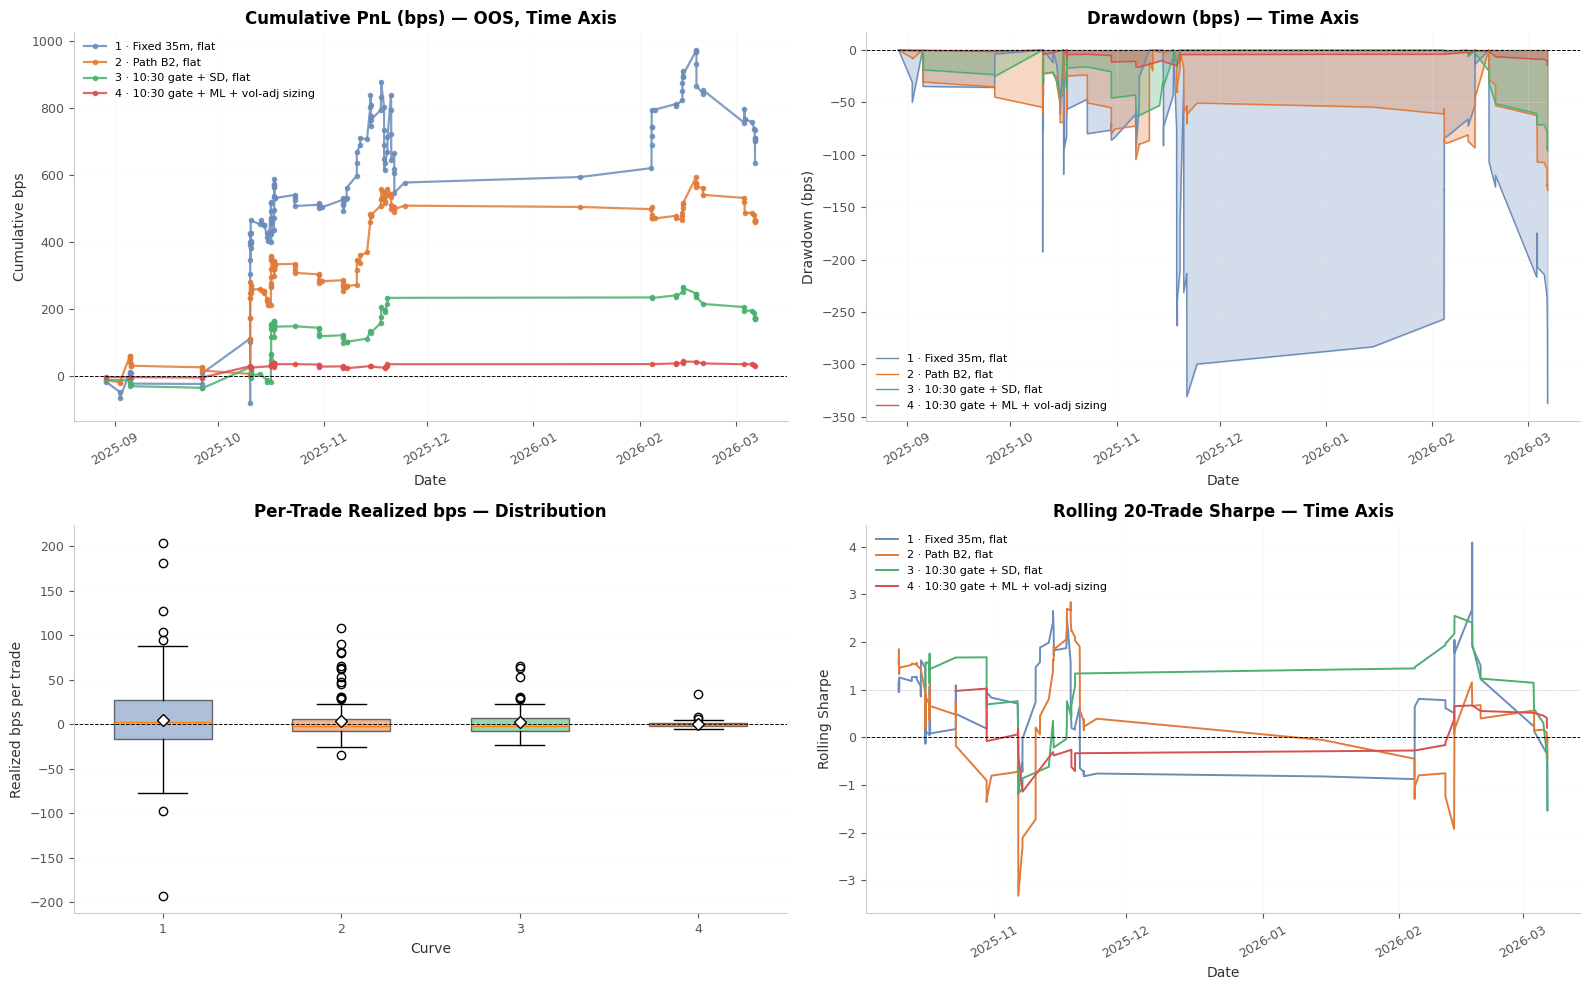


Summary Metrics — OOS Period
                                          n  win%  avg_bps  total_bps  max_dd_bps  sharpe  sortino  calmar
1 · Fixed 35m, flat                  140.00 52.10     4.54     635.60     -337.20    1.15     1.73    1.89
2 · Path B2, flat                    140.00 38.60     3.29     459.90     -133.90    1.74     5.69    3.43
3 · 10:30 gate + SD, flat             75.00 38.70     2.27     170.30      -96.20    1.18     3.43    1.77
4 · 10:30 gate + ML + vol-adj sizing  47.00 36.20     0.63      29.80      -16.20    0.75     2.92    1.83

Per-Trade Quality (curve-count agnostic)
                               curve  n_trades  avg_bps  median_bps  std_bps  win_pct  profit_factor  sharpe
                 1 · Fixed 35m, flat       140     4.54        2.27    46.65     52.1           1.33   1.151
                   2 · Path B2, flat       140     3.29       -1.92    22.31     38.6           1.65   1.742
           3 · 10:30 gate + SD, flat        75     2.27       -1.8

In [23]:
colors = ["#6b8cba", "#e07b39", "#4caf70", "#d94f4f"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
ax_eq, ax_dd, ax_box, ax_rs = axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]

# ── 1. Equity curve on TIME axis (fair across different trade counts) ──────
for (label, pnl), color in zip(curves.items(), colors):
    if pnl.empty:
        continue
    cum = pnl.sort_index().cumsum()
    ax_eq.plot(cum.index, cum.values, label=label, color=color,
               linewidth=1.6, marker="o", markersize=3, alpha=0.85)

ax_eq.axhline(0, color="black", linewidth=0.7, linestyle="--")
ax_eq.set_title("Cumulative PnL (bps) — OOS, Time Axis", fontsize=12, fontweight="bold")
ax_eq.set_ylabel("Cumulative bps")
ax_eq.set_xlabel("Date")
ax_eq.legend(fontsize=8, loc="upper left")
ax_eq.grid(alpha=0.25)
ax_eq.tick_params(axis="x", rotation=30)

# ── 2. Drawdown on TIME axis ───────────────────────────────────────────────
for (label, pnl), color in zip(curves.items(), colors):
    if pnl.empty:
        continue
    cum = pnl.sort_index().cumsum()
    dd  = cum - cum.cummax()
    ax_dd.fill_between(dd.index, dd.values, 0, alpha=0.30, color=color)
    ax_dd.plot(dd.index, dd.values, color=color, linewidth=1.0, label=label)

ax_dd.axhline(0, color="black", linewidth=0.7, linestyle="--")
ax_dd.set_title("Drawdown (bps) — Time Axis", fontsize=12, fontweight="bold")
ax_dd.set_ylabel("Drawdown (bps)")
ax_dd.set_xlabel("Date")
ax_dd.legend(fontsize=8, loc="lower left")
ax_dd.grid(alpha=0.25)
ax_dd.tick_params(axis="x", rotation=30)

# ── 3. Per-trade bps distribution (quality, not scale) ─────────────────────
box_data   = [pnl.dropna().values for pnl in curves.values() if not pnl.empty]
box_labels = [label.split("·")[0].strip() for label, pnl in curves.items() if not pnl.empty]
bp = ax_box.boxplot(box_data, labels=box_labels, patch_artist=True,
                    widths=0.55, showmeans=True,
                    meanprops=dict(marker="D", markerfacecolor="white",
                                    markeredgecolor="black", markersize=6))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)
ax_box.axhline(0, color="black", linewidth=0.7, linestyle="--")
ax_box.set_title("Per-Trade Realized bps — Distribution", fontsize=12, fontweight="bold")
ax_box.set_ylabel("Realized bps per trade")
ax_box.set_xlabel("Curve")
ax_box.grid(alpha=0.25, axis="y")

# ── 4. Rolling 20-trade Sharpe (risk-adjusted quality over time) ───────────
ROLL = 20
for (label, pnl), color in zip(curves.items(), colors):
    clean = pnl.dropna()
    if len(clean) < ROLL:
        continue
    roll_mu    = clean.rolling(ROLL).mean()
    roll_sd    = clean.rolling(ROLL).std().replace(0, np.nan)
    roll_sharpe = (roll_mu / roll_sd) * np.sqrt(ROLL)
    ax_rs.plot(roll_sharpe.index, roll_sharpe.values,
               label=label, color=color, linewidth=1.4)

ax_rs.axhline(0,   color="black", linewidth=0.7, linestyle="--")
ax_rs.axhline(1.0, color="grey",  linewidth=0.6, linestyle=":", alpha=0.6)
ax_rs.set_title(f"Rolling {ROLL}-Trade Sharpe — Time Axis",
                fontsize=12, fontweight="bold")
ax_rs.set_ylabel("Rolling Sharpe")
ax_rs.set_xlabel("Date")
ax_rs.legend(fontsize=8, loc="best")
ax_rs.grid(alpha=0.25)
ax_rs.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

# ── Summary table ──────────────────────────────────────────────────────────
summary = pd.DataFrame(
    {name: equity_metrics(pnl) for name, pnl in curves.items()}
).T

print("\nSummary Metrics — OOS Period")
print("=" * 88)
print(summary.to_string(float_format="{:.2f}".format))

# ── Per-trade quality table (the "fair" comparison) ────────────────────────
quality_rows = []
for name, pnl in curves.items():
    clean = pnl.dropna()
    if len(clean) == 0:
        continue
    quality_rows.append({
        "curve":          name,
        "n_trades":       len(clean),
        "avg_bps":        round(clean.mean(),    2),
        "median_bps":     round(clean.median(),  2),
        "std_bps":        round(clean.std(),     2),
        "win_pct":        round((clean > 0).mean() * 100, 1),
        "profit_factor":  round(clean[clean > 0].sum() / abs(clean[clean < 0].sum()), 2)
                          if (clean < 0).any() else float("inf"),
        "sharpe":         round(clean.mean() / (clean.std() or 1e-9) * np.sqrt(len(clean)), 3),
    })

print("\nPer-Trade Quality (curve-count agnostic)")
print("=" * 100)
print(pd.DataFrame(quality_rows).to_string(index=False))

## 12. Sizing Sensitivity Analysis

How robust is Curve 4 to the choice of `TARGET_RISK_BPS`? Re-run with a range of target-risk values to confirm the result isn't an artifact of one arbitrarily chosen number.


In [24]:
sensitivity_rows = []
for target in [5.0, 7.5, 10.0, 12.5, 15.0, 20.0]:
    sizes_s = compute_position_sizes(approved_events, approved_prob.values,
                                      target_risk_bps=target)
    pnl_s   = (c4_realized * sizes_s).dropna()
    metrics = equity_metrics(pnl_s)
    metrics["target_risk_bps"] = target
    metrics["avg_size"]        = round(float(sizes_s.mean()), 3)
    sensitivity_rows.append(metrics)

sens_df = pd.DataFrame(sensitivity_rows).set_index("target_risk_bps")
print("Curve 4 sensitivity to TARGET_RISK_BPS:")
print("=" * 80)
print(sens_df.to_string(float_format="{:.2f}".format))


Curve 4 sensitivity to TARGET_RISK_BPS:
                  n  win%  avg_bps  total_bps  max_dd_bps  sharpe  sortino  calmar  avg_size
target_risk_bps                                                                             
5.0              47 36.20     0.26      12.30      -16.20    0.46     1.20    0.76      0.25
7.5              47 36.20     0.44      20.70      -16.20    0.63     2.03    1.28      0.25
10.0             47 36.20     0.63      29.80      -16.20    0.75     2.92    1.83      0.26
12.5             47 36.20     0.84      39.50      -16.20    0.83     3.87    2.43      0.26
15.0             47 36.20     1.03      48.30      -16.20    0.87     4.49    2.97      0.27
20.0             47 36.20     1.37      64.50      -18.10    0.90     5.10    3.58      0.30


## 13. Results & Interpretation

### Out-of-Sample Performance

| Curve | n | Sharpe | Calmar | Profit Factor | Max DD (bps) |
|---|---:|---:|---:|---:|---:|
| 1 · Fixed 35m, flat                  | 140 | 1.15 | 1.89 | 1.33 | −337 |
| 2 · Path B2, flat                    | 140 | **1.74** | **3.43** | **1.65** | −134 |
| 3 · 10:30 gate + SD, flat            |  75 | 1.18 | 1.77 | 1.52 |  −96 |
| 4 · 10:30 gate + ML + sized          |  47 | 0.75 | 1.83 | 1.53 |  −16 |

### Layer-by-Layer Attribution

- **Path B2 exit (C1 → C2).** Material improvement. Sharpe rose from 1.15 to 1.74 and max drawdown contracted by 60%. The dynamic momentum-reversal exit dominates the fixed 35-minute hold.
- **10:30 gate + SD band (C2 → C3).** Net negative. The filter removed 46% of trades but Sharpe declined to 1.18, indicating the gate excluded profitable post-open trades alongside the volatile ones.
- **ML filter + volatility-adjusted sizing (C3 → C4).** Net negative. Sharpe fell to 0.75 and OOS ROC-AUC of 0.599 confirms the classifier offers minimal discriminatory power.

### Diagnosis of the ML Layer

1. **Sample-to-feature ratio is insufficient.** 326 in-sample events against 14 features (≈23 events per feature, ≈7 per positive label) is below the threshold required for stable logistic regression coefficients.
2. **Sizing did not engage.** Classifier probabilities cluster near 0.50, which collapses the confidence multiplier and pins position size at the `MIN_SIZE` floor for all approved trades. C4's results therefore reflect a flat 0.25× scalar applied to the ML-filtered subset — the differential sizing mechanism was never meaningfully exercised.
3. **In-sample signal does not generalize.** MACD components and `rolling_std_nq` carry the largest standardized coefficients but the OOS AUC indicates these relationships do not transfer at the current sample size.

### Conclusion

**Curve 2 — Path B2 exit with no entry filter and flat sizing — is the strongest configuration on this dataset.** Sharpe 1.74, Calmar 3.43, and profit factor 1.65 across 140 out-of-sample trades. The additional layers introduced in v2 did not survive out-of-sample validation.

### Recommendations

- **Retain** the Path B2 dynamic exit as the production exit rule.
- **Reassess** the 10:30 gate against a wider volatility band, or as a softer modulator of position size rather than a binary entry filter.
- **Defer** the ML quality filter until either (a) the training set is materially larger, or (b) the feature set is reduced to those with stable cross-period signal — MACD-derived features being the leading candidates.
- **Re-test** pure inverse-volatility sizing without the ML confidence multiplier as an isolated experiment; the current design did not provide a clean read on its standalone contribution.